In [11]:
from pathlib import Path
import torch
import torch.nn as nn
import numpy as np
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')


In [ ]:
# --- COMPILA QUESTI PARAMETRI IN BASE AL TUO TRAINING ---
NUM_ASSETS = 362  # Sostituisci con la lunghezza reale del vettore appiattito
HIDDEN_DIMS = [2048, 1024, 512] # Sostituisci con l'architettura esatta usata
LATENT_DIM = 20
FILE_NAME = "data_00_20"
WINDOW_LENGTH = 724
STRIDE = 10
DATASET_NAME = f"{FILE_NAME}_w{WINDOW_LENGTH}_s{STRIDE}" # Sostituisci con il nome esatto del dataset usato
INPUT_DIM = NUM_ASSETS * (NUM_ASSETS - 1) // 2
RUN_NAME = "VAE_20dim_cholesky_02" # Sostituisci con il nome esatto del run usato
N_MATRICES = 100 # Numero di scenari di correlazione che vuoi generare


In [13]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], latent_dim: int):
        super().__init__()

        # Encoder
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers.append(nn.Linear(prev, h))
            enc_layers.append(nn.LeakyReLU(0.01))
            prev = h
        self.encoder = nn.Sequential(*enc_layers)

        self.fc_mu = nn.Linear(prev, latent_dim)
        self.fc_logvar = nn.Linear(prev, latent_dim)

        # Decoder
        dec_layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec_layers.append(nn.Linear(prev, h))
            dec_layers.append(nn.LeakyReLU(0.01))
            prev = h
        dec_layers.append(nn.Linear(prev, input_dim))
        #dec_layers.append(nn.Tanh())
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x: torch.Tensor):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        sample = mu + (eps * std)
        return sample

    def decode(self, z: torch.Tensor):
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        if self.training:
            # Durante l'addestramento (model.train()), usa il campionamento stocastico
            z = self.reparameterize(mu, logvar)
        else:
            # Durante la validazione/test (model.eval()), usa l'aspettativa esatta
            z = mu
        x_hat = self.decode(z)
        return x_hat, mu, logvar

In [14]:
# Setup del device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resume_source_path = Path(rf"..\models\{DATASET_NAME}\VAE\{RUN_NAME}\best_model.pt")

# --- LOAD E CONTROLLO DEL CHECKPOINT ---
checkpoint = torch.load(resume_source_path, map_location=device)
state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint

# Inizializziamo il modello (funge anche da probe_model per i check)
model = VAE(
    input_dim=INPUT_DIM,
    latent_dim=LATENT_DIM,
    hidden_dims=HIDDEN_DIMS,
)

current_shapes = {k: tuple(v.shape) for k, v in model.state_dict().items()}
loaded_shapes = {k: tuple(v.shape) for k, v in state_dict.items()}

missing_keys = [k for k in current_shapes.keys() if k not in loaded_shapes]
unexpected_keys = [k for k in loaded_shapes.keys() if k not in current_shapes]
shape_mismatches = [
    (k, loaded_shapes[k], current_shapes[k])
    for k in current_shapes.keys()
    if k in loaded_shapes and loaded_shapes[k] != current_shapes[k]
]

if missing_keys or shape_mismatches or unexpected_keys:
    suggested_hidden = []
    # Cerchiamo tutti i pesi dei layer lineari nell'encoder
    for key, weight in state_dict.items():
        if key.startswith('encoder.') and key.endswith('.weight'):
            # Escludiamo il primo strato (input_dim -> hidden[0])
            if weight.shape[1] == INPUT_DIM:
                continue
            suggested_hidden.append(int(weight.shape[0]))

    # L'ultimo elemento trovato sara il latent_dim
    if suggested_hidden:
        ckpt_latent_dim = suggested_hidden[-1]
        ckpt_hidden_dims = suggested_hidden[:-1]
        hint = (
            f'Checkpoint expects latent_dim={ckpt_latent_dim}, '
            f'hidden_dims={ckpt_hidden_dims}. '
            'Set these values to match before resuming, or start a new run without resume.'
        )
    else:
        hint = 'Checkpoint architecture could not be inferred. Use a checkpoint saved with the same model architecture.'

    details = []
    if missing_keys:
        details.append(f'Missing keys (first 5): {missing_keys[:5]}')
    if unexpected_keys:
        details.append(f'Unexpected keys (first 5): {unexpected_keys[:5]}')
    if shape_mismatches:
        k, loaded_shape, current_shape = shape_mismatches[0]
        details.append(f'Shape mismatch example: {k} loaded={loaded_shape}, current={current_shape}')

    raise RuntimeError(
        'Incompatible checkpoint for current VAE architecture. ' + hint + (' | ' + ' ; '.join(details) if details else '')
    )
else:
    # Se i controlli sulle shape passano, applichiamo i pesi
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print("Controllo di integrità superato: Pesi caricati correttamente.")
    print(f"Modello impostato in modalità eval() sul device: {device}")

Controllo di integrità superato: Pesi caricati correttamente.
Modello impostato in modalità eval() sul device: cuda


In [15]:
print(model)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=65341, out_features=2048, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=2048, out_features=1024, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (fc_mu): Linear(in_features=512, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=512, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=512, out_features=1024, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=1024, out_features=2048, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=2048, out_features=65341, bias=True)
  )
)


In [16]:
def reconstruct_correlation_matrices(flat_matrices, n_assets):
    """Ricostruisce le matrici di correlazione simmetriche con clipping."""
    if hasattr(flat_matrices, 'detach'):
        flat_matrices = flat_matrices.detach().cpu().numpy()
        
    n_matrices = flat_matrices.shape[0]
    recon_corr = np.zeros((n_matrices, n_assets, n_assets), dtype=np.float32)
    tril_idx = np.tril_indices(n_assets, k=-1)
    
    recon_corr[:, tril_idx[0], tril_idx[1]] = flat_matrices
    recon_corr[:, tril_idx[1], tril_idx[0]] = flat_matrices

    diag_idx = np.arange(n_assets)
    recon_corr[:, diag_idx, diag_idx] = 1.0
    
    # Aggiunto il clipping rigoroso tra -1 e 1
    recon_corr = np.clip(recon_corr, -1.0, 1.0)
    
    return recon_corr

In [37]:
# =====================================================================
# SEZIONE BOOTSTRAPPING STORICO CON NORMALIZZAZIONE
# =====================================================================

print("\n--- Inizio Bootstrapping Storico (Sottoinsieme Casuale) ---")

# 1. Caricamento del dataset reale
dataset_path = Path(rf"..\data\processed\{FILE_NAME}\dataset\{DATASET_NAME}\all.pt")
print(f"Caricamento dataset da: {dataset_path}")

try:
    payload = torch.load(dataset_path, map_location=device, weights_only=False)
except TypeError:
    payload = torch.load(dataset_path, map_location=device)

historical_data = payload['corr_tensor'].to(device).float()

if historical_data.ndim == 3:
    N_MATRICES, N_ASSETS, _ = historical_data.shape
    tril_idx = torch.tril_indices(row=N_ASSETS, col=N_ASSETS, offset=-1)
    historical_data = historical_data[:, tril_idx[0], tril_idx[1]]

# --- CARICAMENTO STATISTICHE E NORMALIZZAZIONE ---
# Ricostruiamo i percorsi esatti usati durante il salvataggio
mean_path = Path(rf"..\models\{DATASET_NAME}\VAE\{RUN_NAME}\train_mean.pt")
std_path = Path(rf"..\models\{DATASET_NAME}\VAE\{RUN_NAME}\train_std.pt")

print(f"Caricamento train_mean da: {mean_path}")
print(f"Caricamento train_std da: {std_path}")

# weights_only=True è una buona pratica di sicurezza per il caricamento di soli tensori
train_mean = torch.load(mean_path, map_location=device, weights_only=True)
train_std = torch.load(std_path, map_location=device, weights_only=True)

# Applichiamo la Z-score normalization prima dell'encoder
historical_data_norm = (historical_data - train_mean) / train_std
print("Dati storici normalizzati con successo.")
# ---------------------------------------------------------

N_SCENARIOS = 100 
FORECAST_LAG = 2   

with torch.no_grad():
    # 2. Codifica dell'intera storia (USIAMO I DATI NORMALIZZATI)
    z_history, _ = model.encode(historical_data_norm)
    
    # 3. Calcolo delle transizioni storiche (Deltas)
    z_t_plus_2 = z_history[FORECAST_LAG:]
    z_t = z_history[:-FORECAST_LAG]
    
    historical_deltas = z_t_plus_2 - z_t
    n_available_deltas = historical_deltas.shape[0]
    
    if N_SCENARIOS > n_available_deltas:
        raise ValueError(f"N_SCENARIOS ({N_SCENARIOS}) non può essere maggiore dei salti disponibili ({n_available_deltas}).")
    
    # 4. Stato attuale 
    z_oggi = z_history[-1]
    
    # 5. Bootstrapping SENZA reinserimento
    random_indices = torch.randperm(n_available_deltas, device=device)[:N_SCENARIOS]
    sampled_deltas = historical_deltas[random_indices]
    
    # 6. Generazione scenari futuri nello spazio latente
    z_futuro = z_oggi.unsqueeze(0) + sampled_deltas
    
    # 7. Decodifica (L'output è ancora nello spazio Z-score normalizzato)
    generated_flat_matrices_norm = model.decode(z_futuro)

# --- DENORMALIZZAZIONE DELL'OUTPUT ---
# Invertiamo la normalizzazione sfruttando il broadcasting di PyTorch
generated_flat_matrices = (generated_flat_matrices_norm * train_std) + train_mean
print("Output del decoder denormalizzato con successo.")
# ---------------------------------------------

# 8. Ricostruzione in matrici quadrate simmetriche
final_correlation_matrices = reconstruct_correlation_matrices(generated_flat_matrices, NUM_ASSETS)
print(f"Shape matrici di correlazione previste finali: {final_correlation_matrices.shape}")

# Salvataggio
output_save_path = Path(rf"..\generated_matrices\{DATASET_NAME}\{RUN_NAME}\forecast_scenarios_{N_SCENARIOS}\forecast_scenarios_{N_SCENARIOS}.pt")
# Crea la cartella (e le cartelle genitore) se non esistono già
output_save_path.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    'forecast_matrices': final_correlation_matrices,
    'z_oggi': z_oggi.cpu(),
    'sampled_deltas': sampled_deltas.cpu(), 
}, output_save_path)

print(f"Scenari salvati con successo in: {output_save_path}")


--- Inizio Bootstrapping Storico (Sottoinsieme Casuale) ---
Caricamento dataset da: ..\data\processed\data_00_20\dataset\data_00_20_w724_s10\all.pt
Caricamento train_mean da: ..\models\data_00_20_w724_s10\VAE\VAE_20dim_0002\train_mean.pt
Caricamento train_std da: ..\models\data_00_20_w724_s10\VAE\VAE_20dim_0002\train_std.pt
Dati storici normalizzati con successo.
Output del decoder denormalizzato con successo.
Shape matrici di correlazione previste finali: (100, 362, 362)
Scenari salvati con successo in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_0002\forecast_scenarios_100\forecast_scenarios_100.pt


Grafico dello Scenario 0 salvato con successo in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_0002\forecast_scenarios_100\idx_0\forecast_chart_scenario_0.png


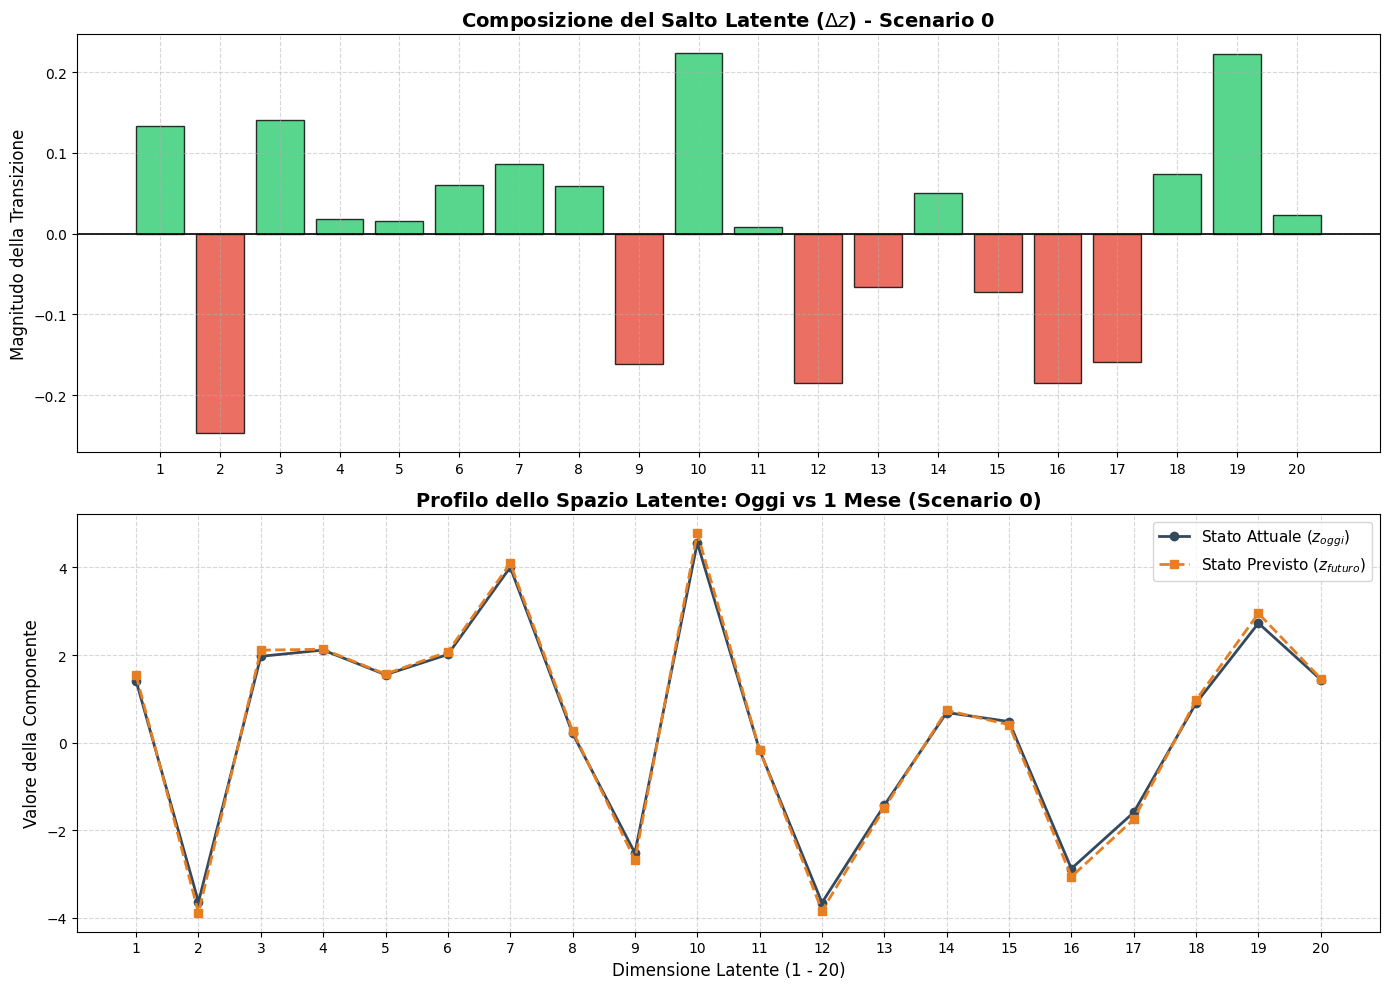

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# --- PARAMETRO DA SCEGLIERE ---
IDX = 0  # Cambia questo valore (da 0 a N_SCENARIOS - 1) per esplorare scenari diversi

# Controlli di sicurezza
if IDX < 0 or IDX >= N_SCENARIOS:
    raise ValueError(f"L'indice IDX deve essere compreso tra 0 e {N_SCENARIOS - 1}.")

# Estrazione dei dati e conversione in array numpy
# Utilizziamo sampled_deltas per esplorare uno degli scenari effettivamente generati
delta_vector = sampled_deltas[IDX].cpu().numpy()
z_oggi_np = z_oggi.cpu().numpy()
z_futuro_np = z_oggi_np + delta_vector

# Asse x per le 20 dimensioni
dimensioni = np.arange(1, LATENT_DIM + 1)

# Impostazione della figura con due subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# 1. Plot del vettore Delta (Il Salto)
colori_delta = ['#e74c3c' if val < 0 else '#2ecc71' for val in delta_vector] # Rosso per i cali, verde per gli aumenti
ax1.bar(dimensioni, delta_vector, color=colori_delta, alpha=0.8, edgecolor='black')
ax1.axhline(0, color='black', linewidth=1.2)
ax1.set_title(rf"Composizione del Salto Latente ($\Delta z$) - Scenario {IDX}", fontsize=14, fontweight='bold')
ax1.set_ylabel("Magnitudo della Transizione", fontsize=12)
ax1.set_xticks(dimensioni)
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Plot del Confronto: Oggi vs Futuro
ax2.plot(dimensioni, z_oggi_np, marker='o', linestyle='-', color='#34495e', label="Stato Attuale ($z_{oggi}$)", linewidth=2)
ax2.plot(dimensioni, z_futuro_np, marker='s', linestyle='--', color='#e67e22', label=f"Stato Previsto ($z_{{futuro}}$)", linewidth=2)
ax2.set_title(f"Profilo dello Spazio Latente: Oggi vs 1 Mese (Scenario {IDX})", fontsize=14, fontweight='bold')
ax2.set_xlabel("Dimensione Latente (1 - 20)", fontsize=12)
ax2.set_ylabel("Valore della Componente", fontsize=12)
ax2.set_xticks(dimensioni)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

# Layout e rendering
plt.tight_layout()
# --- SALVATAGGIO DELLA FIGURA NELLO STESSO PERCORSO DEL FORECAST ---
# Definiamo la cartella di output (la stessa di forecast_scenarios_N.pt)
plots_dir = Path(rf"..\generated_matrices\{DATASET_NAME}\{RUN_NAME}\forecast_scenarios_{N_SCENARIOS}\idx_{IDX}")
plots_dir.mkdir(parents=True, exist_ok=True)

# Definiamo il percorso del file per il grafico corrente
plot_save_path = plots_dir / f"forecast_chart_scenario_{IDX}.png"

# Salviamo il grafico prima di plt.show() altrimenti l'immagine salvata risulterebbe vuota
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
print(f"Grafico dello Scenario {IDX} salvato con successo in: {plot_save_path}")

# Mostra il grafico a schermo
plt.show()

In [39]:
# Definiamo il percorso del file JSON
tickers_path = Path(r"..\data\processed\data_00_20\data_00_20_tickers.json")

# Carichiamo i dati
with open(tickers_path, 'r', encoding='utf-8') as f:
    tickers = json.load(f)


# Verifica di integrità
print(f"Caricamento completato: trovati {len(tickers)} ticker.")

if len(tickers) == NUM_ASSETS:
    print("Check superato: il numero di ticker corrisponde esattamente a NUM_ASSETS.")
else:
    print(f"ATTENZIONE: Mismatch rilevato. Ticker caricati = {len(tickers)}, NUM_ASSETS = {NUM_ASSETS}.")

# Mostriamo i primi 10 ticker come test visivo
print(f"Primi 10 ticker: {tickers[:10]}")

Caricamento completato: trovati 362 ticker.
Check superato: il numero di ticker corrisponde esattamente a NUM_ASSETS.
Primi 10 ticker: ['AAPL', 'ABC', 'ABMD', 'ABT', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE']


Shape matrice sintetica da visualizzare: (362, 362)
Valori min/max matrice sintetica: 0.0122 / 1.0000


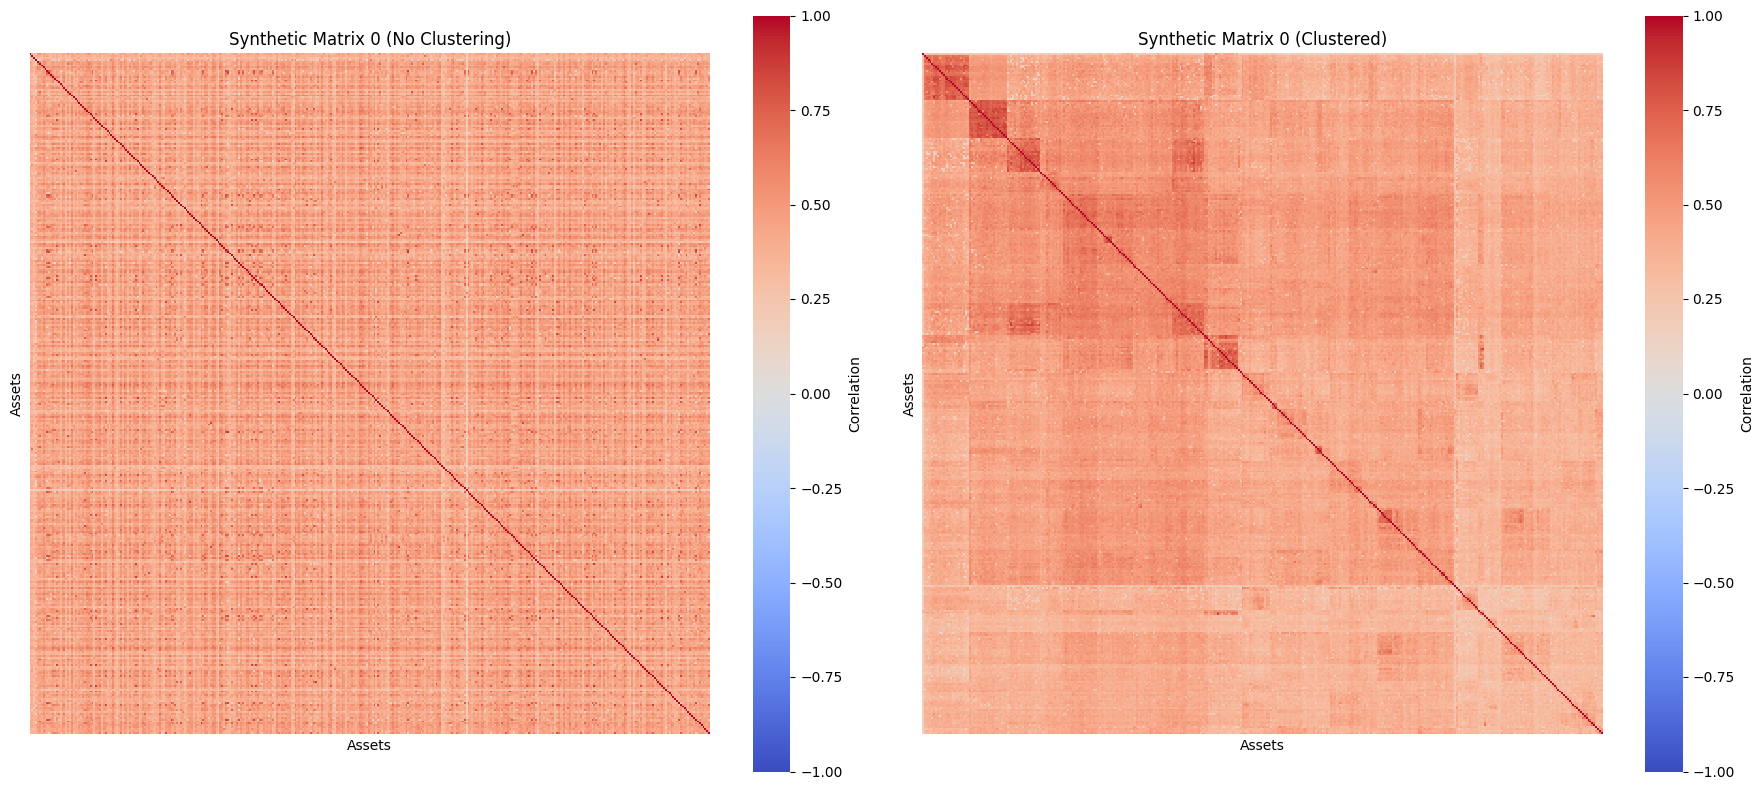

Heatmap salvate per la matrice generata (indice 0):
 - ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_0002\forecast_scenarios_100\idx_0\property0\synthetic_heatmaps_original.png


In [40]:
print(f"Shape matrice sintetica da visualizzare: {final_correlation_matrices[IDX].shape}")
print(f"Valori min/max matrice sintetica: {final_correlation_matrices[IDX].min():.4f} / {final_correlation_matrices[IDX].max():.4f}")

def plot_synthetic_matrix_and_save(synth_mat, version, base_out_dir, sample_idx=0):
    """
    Genera e salva due heatmap (standard e clusterizzata) per esplorare 
    visivamente una singola matrice di correlazione generata dal VAE.
    """
    # 1. Setup cartelle per i dati sintetici
    SAMPLE_FOLDER = Path(base_out_dir) / "property0"
    SAMPLE_FOLDER.mkdir(parents=True, exist_ok=True)

    shared_cmap = 'coolwarm'

    # 2. Calcolo del clustering direttamente sulla matrice sintetica
    cluster_ref = sns.clustermap(
        synth_mat,
        vmin=-1, vmax=1,
        cmap=shared_cmap,
        linewidths=0,
        figsize=(8, 8)
    )
    row_order = cluster_ref.dendrogram_row.reordered_ind
    col_order = cluster_ref.dendrogram_col.reordered_ind
    plt.close(cluster_ref.figure) # Chiudiamo la figura di background

    # 3. Riordino della matrice in base al clustering
    synth_mat_clustered = synth_mat[np.ix_(row_order, col_order)]

    # ==========================================
    # PLOT: MATRICE SINTETICA AFFIANCATA (Standard vs Clustered)
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # --- Pannello 1: Ordine Originale ---
    sns.heatmap(
        synth_mat, ax=axes[0], vmin=-1, vmax=1, 
        cmap=shared_cmap, square=True,
        xticklabels=False, yticklabels=False, # <-- Ticker rimossi
        cbar_kws={'label': 'Correlation'}
    )
    axes[0].set_title(f'Synthetic Matrix {sample_idx} (No Clustering)')

    # --- Pannello 2: Ordine Clusterizzato ---
    sns.heatmap(
        synth_mat_clustered, ax=axes[1], vmin=-1, vmax=1, 
        cmap=shared_cmap, square=True,
        xticklabels=False, yticklabels=False, # <-- Ticker rimossi
        cbar_kws={'label': 'Correlation'}
    )
    axes[1].set_title(f'Synthetic Matrix {sample_idx} (Clustered)')

    # Formattazione assi (rimosse anche le tacchette)
    for ax in axes:
        ax.set_xlabel('Assets')
        ax.set_ylabel('Assets')
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    path_out = SAMPLE_FOLDER / f'synthetic_heatmaps_{version}.png'
    fig.savefig(path_out, dpi=300, bbox_inches='tight')
    plt.show()

    print(f'Heatmap salvate per la matrice generata (indice {sample_idx}):')
    print(f' - {path_out}')


# --- ESEMPIO DI UTILIZZO ---
synth_mat = final_correlation_matrices[IDX]

# Passo comunque 'tickers' per compatibilità con la firma della funzione, anche se non visualizzati
plot_synthetic_matrix_and_save(synth_mat, 'original', plots_dir, sample_idx=IDX)

In [44]:
print(f"Computing eigendecomposition for synthetic matrix (IDX={IDX})...")
# Calcoliamo autovalori (evals) e autovettori (evecs)
# np.linalg.eigh restituisce gli autovalori in ordine crescente
evals_synth, evecs_synth = np.linalg.eigh(synth_mat)

# Invertiamo l'ordine per avere quelli decrescenti (highest eigenvalues first)
# In NumPy, [::-1] inverte l'array lungo l'asse specificato
evals_synth = evals_synth[::-1]
evecs_synth = evecs_synth[:, ::-1]

print("✓ Eigendecomposition complete!")

# Analisi di validità finanziaria (Positività della matrice)
negative_eigenvalues_count_synth = np.sum(evals_synth < 0)

print(f"\n--- Spectral Properties (Synthetic Matrix IDX={IDX}) ---")
print(f"Number of negative eigenvalues: {negative_eigenvalues_count_synth}")

if negative_eigenvalues_count_synth > 0:
    min_eval = np.min(evals_synth)
    print(f"Magnitude of the most negative eigenvalue: {min_eval:.6f}")
    print("Nota: La matrice non è strettamente definita positiva. "
          "Potrebbe essere necessario applicare un algoritmo di 'nearest correlation matrix' "
          "prima di usarla per l'ottimizzazione del portafoglio.")
else:
    print("La matrice è semi-definita positiva (PSD). Ottimo risultato generativo!")

Computing eigendecomposition for synthetic matrix (IDX=0)...
✓ Eigendecomposition complete!

--- Spectral Properties (Synthetic Matrix IDX=0) ---
Number of negative eigenvalues: 106
Magnitude of the most negative eigenvalue: -1.442030
Nota: La matrice non è strettamente definita positiva. Potrebbe essere necessario applicare un algoritmo di 'nearest correlation matrix' prima di usarla per l'ottimizzazione del portafoglio.


In [49]:
def make_nearest_correlation_matrix_robust(matrix, tol=1e-8, max_iter=200):
    """
    Applica Higham per avvicinarsi alla matrice ideale, ma utilizza la 
    normalizzazione di Sylvester finale per garantire matematicamente una matrice PSD.
    """
    A = (matrix + matrix.T) / 2.0
    delta_S = np.zeros_like(A)
    Y = np.copy(A)
    
    # 1. Fase di convergenza (Higham)
    for i in range(max_iter):
        R = Y - delta_S
        
        # Proiezione PSD
        evals, evecs = np.linalg.eigh(R)
        evals_clipped = np.maximum(evals, 1e-10) # Tolleranza irremovibile > 0
        X = evecs @ np.diag(evals_clipped) @ evecs.T
        
        delta_S = X - R
        
        # Proiezione Diagonale
        Y = np.copy(X)
        np.fill_diagonal(Y, 1.0)
        
        diff = np.max(np.abs(X - Y))
        if diff < tol:
            print(f"Higham convergente in {i+1} iterazioni.")
            break
            
    # 2. FASE DI GARANZIA PSD (Sylvester)
    # Ignoriamo Y (che ci rovina gli autovalori) e prendiamo X (che è puramente PSD).
    # Normalizziamo la diagonale di X matematicamente.
    diag_elements = np.maximum(np.diag(X), 1e-12)
    inv_sqrt_diag = 1.0 / np.sqrt(diag_elements)
    
    # C = D^(-1/2) * X * D^(-1/2)
    final_matrix = X * np.outer(inv_sqrt_diag, inv_sqrt_diag)
    
    # Pulizia finale millimetrica per la precisione di macchina
    final_matrix = (final_matrix + final_matrix.T) / 2.0
    np.fill_diagonal(final_matrix, 1.0) # Assicura l'1 esatto dopo la moltiplicazione
    
    return final_matrix

# --- Applicazione e Verifica ---
print("\nApplicazione dell'algoritmo Higham Robusto in corso...")
synth_mat_psd = make_nearest_correlation_matrix_robust(synth_mat)

# Ricalcoliamo gli autovalori per conferma
evals_check, _ = np.linalg.eigh(synth_mat_psd)

# Estraiamo gli autovalori sotto la nostra tolleranza
TOLERANCE = -1e-6
strict_negatives = evals_check[evals_check < TOLERANCE]

print(f"\n--- Analisi Autovalori Post-Correzione Robusta (IDX={IDX}) ---")
print(f"Autovalori strettamente negativi (oltre tolleranza {TOLERANCE}): {len(strict_negatives)}")
print(f"Valori negativi residui (se presenti): {evals_check[evals_check < 0]}")
if len(strict_negatives) == 0:
    print("✓ SUCCESSO: La matrice è rigorosamente Semi-Definita Positiva (PSD).")
else:
    print("⚠ Attenzione: persistono problemi numerici. Valori rimasti:")
    for i, val in enumerate(strict_negatives):
        print(f"  [{i+1}] {val:e}")


Applicazione dell'algoritmo Higham Robusto in corso...

--- Analisi Autovalori Post-Correzione Robusta (IDX=0) ---
Autovalori strettamente negativi (oltre tolleranza -1e-06): 0
Valori negativi residui (se presenti): [-5.9009938e-07 -5.3762392e-07 -5.2032459e-07 -5.0811758e-07
 -5.0091387e-07 -4.9483037e-07 -4.7700848e-07 -4.7226797e-07
 -4.6632320e-07 -4.3912118e-07 -4.2188324e-07 -4.1569405e-07
 -4.0896467e-07 -4.0383199e-07 -3.9534058e-07 -3.9278703e-07
 -3.8244724e-07 -3.7365942e-07 -3.7123544e-07 -3.6329479e-07
 -3.5229868e-07 -3.4757818e-07 -3.4095356e-07 -3.3217569e-07
 -3.1646331e-07 -3.1208933e-07 -3.0342028e-07 -2.9489115e-07
 -2.9170599e-07 -2.8618513e-07 -2.7513306e-07 -2.6958094e-07
 -2.6142456e-07 -2.5462469e-07 -2.5108719e-07 -2.4460806e-07
 -2.4118566e-07 -2.3444018e-07 -2.3327091e-07 -2.2728992e-07
 -2.2127959e-07 -2.0722135e-07 -2.0438439e-07 -1.9679744e-07
 -1.8656374e-07 -1.8190057e-07 -1.7980224e-07 -1.7396476e-07
 -1.6728529e-07 -1.5989649e-07 -1.5795086e-07 -1.53

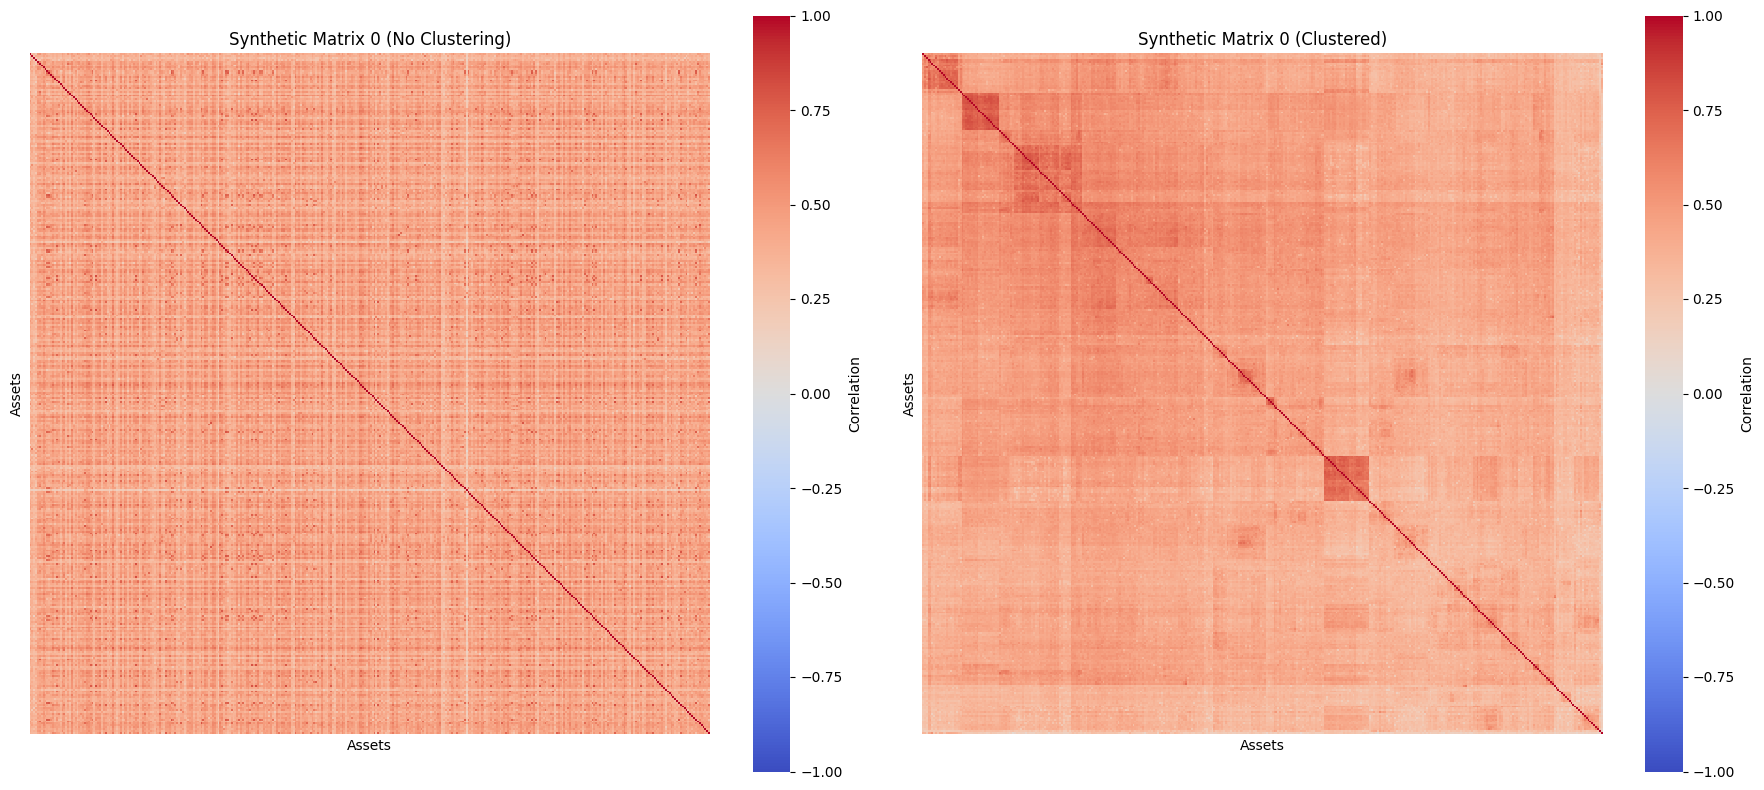

Heatmap salvate per la matrice generata (indice 0):
 - ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_0002\forecast_scenarios_100\idx_0\property0\synthetic_heatmaps_higham.png


In [50]:
plot_synthetic_matrix_and_save(synth_mat_psd, 'higham', plots_dir, sample_idx=IDX)

In [51]:
print(f"Calcolo delle metriche di deformazione per lo scenario sintetico (IDX={IDX})...")

# 1. Matrice delle differenze
diff_matrix = synth_mat - synth_mat_psd

# 2. Mean Squared Error (MSE)
# Calcola la media dei quadrati degli errori. Penalizza fortemente le deviazioni molto ampie.
mse = np.mean(diff_matrix**2)

# 3. Mean Absolute Error (MAE)
# Calcola la media dei valori assoluti. Rappresenta la deviazione media attesa per ogni singolo elemento (correlazione)
mae = np.mean(np.abs(diff_matrix))

# 4. Norma di Frobenius (Distanza Euclidea per matrici)
# Rappresenta la magnitudine complessiva dell'alterazione apportata dall'algoritmo di proiezione
frobenius_dist = np.linalg.norm(diff_matrix, ord='fro')

# --- Stampa dei Risultati ---
print("\n===========================================================")
print(" DISTANZA: MATRICE GENERATA (GREZZA) vs MATRICE CORRETTA (PSD)")
print("===========================================================")
# Usiamo il formato scientifico per MSE e MAE dato che ci aspettiamo valori piccoli
print(f"Mean Squared Error (MSE)  : {mse:.8e}")
print(f"Mean Absolute Error (MAE) : {mae:.8e}")
print(f"Frobenius Norm            : {frobenius_dist:.6f}")
print("===========================================================")

Calcolo delle metriche di deformazione per lo scenario sintetico (IDX=0)...

 DISTANZA: MATRICE GENERATA (GREZZA) vs MATRICE CORRETTA (PSD)
Mean Squared Error (MSE)  : 3.65854619e-04
Mean Absolute Error (MAE) : 1.25220381e-02
Frobenius Norm            : 6.924091


# Property 1: The distribution of pairwise correlations is significantly shifted towards positive values


✓ Distribution plot saved to: ..\generated_matrices\data_00_20_w724_s10\VAE_3dim_0002\idx_1\property1\synthetic_correlation_distribution.png

--- Statistics for Synthetic Matrix (IDX=1) ---
Mean: 0.2348 | Std: 0.0946 | Min: -0.0894 | Max: 0.8490
Positive: 65259 (99.87%) | Negative: 82 (0.13%) | Zero: 0 (0.00%)


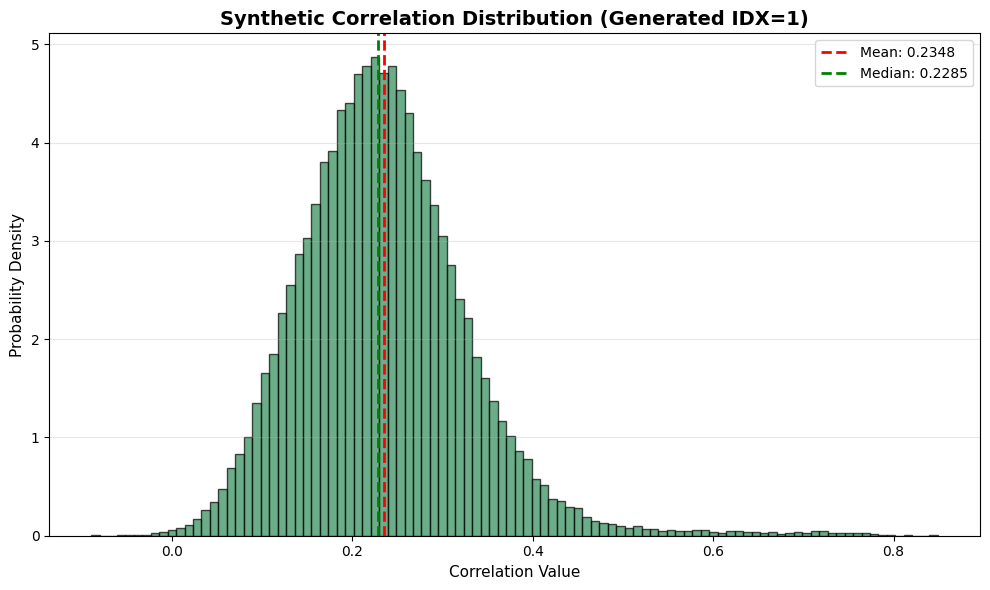

In [59]:
PROPERTY_1_FOLDER = plots_single_dir / 'property1'
PROPERTY_1_FOLDER.mkdir(parents=True, exist_ok=True)

# 1. Estrazione degli indici del triangolo superiore (offset=1 esclude la diagonale di 1.0)
triu_indices = np.triu_indices(NUM_ASSETS, k=1)

# 2. Prepariamo la Matrice Sintetica
synth_values = synth_mat_psd[triu_indices]

# ==========================================
# VISUALIZZAZIONE DELLA DISTRIBUZIONE
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(synth_values, bins=100, color='seagreen', edgecolor='black', alpha=0.7, density=True)

# Aggiunta delle linee per media e mediana
mean_val = np.mean(synth_values)
median_val = np.median(synth_values)
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')

# Formattazione
ax.set_xlabel('Correlation Value', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title(f'Synthetic Correlation Distribution (Generated IDX={IDX})', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Salvataggio
plot_path = PROPERTY_1_FOLDER / 'synthetic_correlation_distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Distribution plot saved to: {plot_path}")

# ==========================================
# STATISTICHE IN CONSOLE
# ==========================================
print(f"\n--- Statistics for Synthetic Matrix (IDX={IDX}) ---")
print(f"Mean: {np.mean(synth_values):.4f} | Std: {np.std(synth_values):.4f} | Min: {np.min(synth_values):.4f} | Max: {np.max(synth_values):.4f}")

pos = np.sum(synth_values > 0)
neg = np.sum(synth_values < 0)
zero = np.sum(synth_values == 0)
total = len(synth_values)

print(f"Positive: {pos} ({100*pos/total:.2f}%) | Negative: {neg} ({100*neg/total:.2f}%) | Zero: {zero} ({100*zero/total:.2f}%)")

plt.show()

# Property 2: Eigenvalues follow the Marchenko–Pastur distribution, except for a very large first eigenvalue and a couple of other large eigenvalues

In [60]:
# Setup della cartella (sempre basata su plots_single_dir per l'indice corrente)
PROPERTY_2_FOLDER = plots_single_dir / 'property2'
PROPERTY_2_FOLDER.mkdir(parents=True, exist_ok=True)

# ===== MARCHENKO-PASTUR FUNCTION =====
def marchenko_pastur_pdf(x, lmbd, sigma=1):
    """
    Marchenko-Pastur probability density function.

    Parameters:
    -----------
    x : float or array
        Eigenvalue
    lmbd : float
        Ratio of num_eigenvalues / num_time_points (N/T)
    sigma : float
        Standard deviation (typically 1 for correlation matrices)

    Returns:
    --------
    float or array
        Probability density at x
    """
    b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)  # Largest eigenvalue
    a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)  # Smallest eigenvalue

    # Vectorized calculation
    result = np.zeros_like(x, dtype=float)
    mask = (x >= a) & (x <= b)
    result[mask] = (1 / (2 * np.pi * sigma * sigma * x[mask] * lmbd)) * np.sqrt((b - x[mask]) * (x[mask] - a))

    return result

✓ RMT Analysis plot saved to: ..\generated_matrices\data_00_20_w724_s10\VAE_3dim_0002\idx_1\property2\synthetic_marchenko_pastur_analysis.png

 ANALISI RANDOM MATRIX THEORY (Sintetica IDX=1)
Parametri MP     : N = 362, T = 724 -> Lambda (λ) = 0.5000
Limiti Teorici   : a (min) = 0.0858 | b (max) = 2.9142
-------------------------------------------------------
Market/Sector Modes (> b)   : 9 autovalori
Noise Bulk (dentro [a, b])  : 311 autovalori
Small Eigenvalues (< a)     : 42 autovalori
-------------------------------------------------------
Max Eigenvalue (Market Mode): 89.4702
Min Eigenvalue              : 1.0000e-10


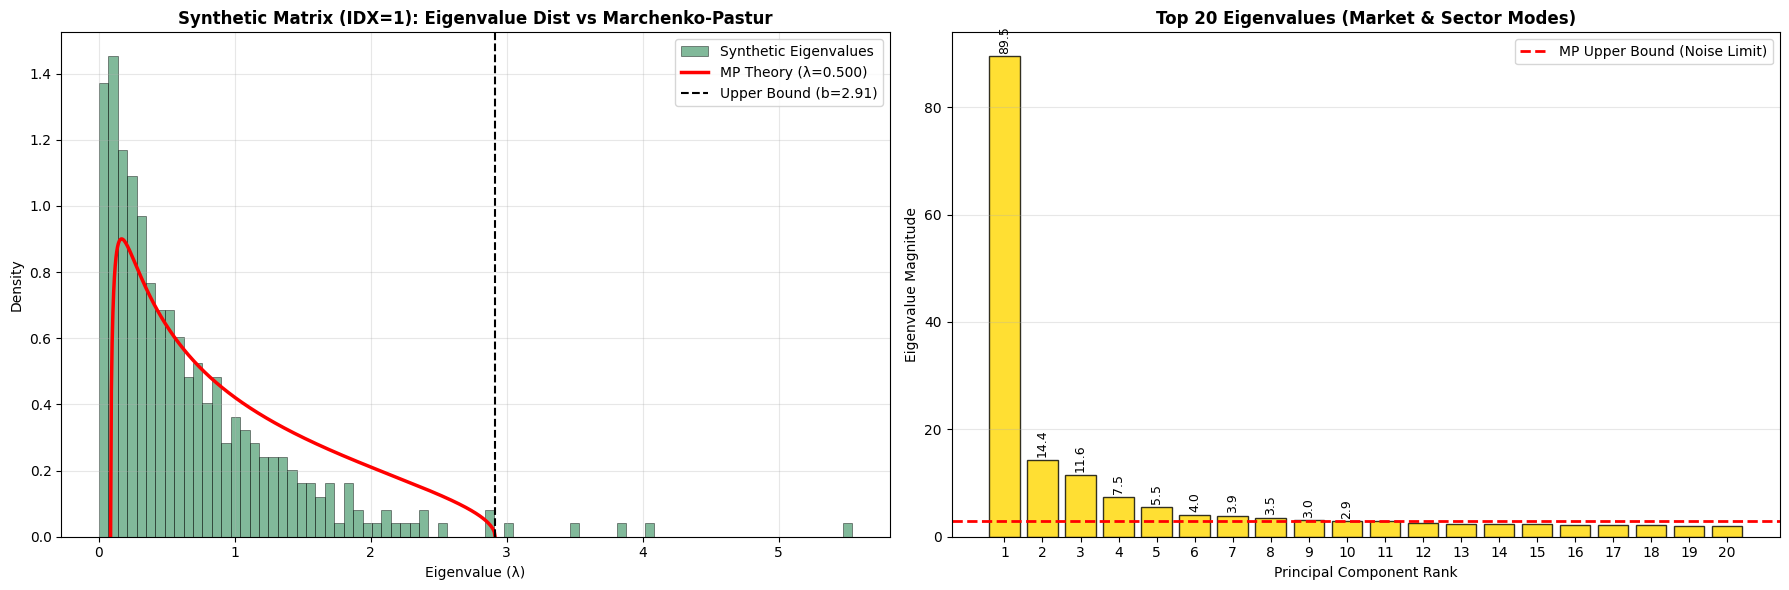

In [61]:
# ==========================================
# 1. SETUP PARAMETRI RMT
# ==========================================
# Dal dataset 'w724', la finestra temporale T è 724.
lmbd = NUM_ASSETS / WINDOW_LENGTH
sigma = 1.0

# Calcolo dei limiti teorici di Marchenko-Pastur
b = np.power(sigma * (1 + np.sqrt(lmbd)), 2) # Limite superiore (rumore massimo)
a = np.power(sigma * (1 - np.sqrt(lmbd)), 2) # Limite inferiore

# Curva teorica
x_theory = np.linspace(a, b, 500)
y_theory = marchenko_pastur_pdf(x_theory, lmbd, sigma)

# ==========================================
# 2. ESTRAZIONE AUTOVALORI MATRICE SINTETICA
# ==========================================
# Utilizziamo la matrice globale (che ora contiene la versione PSD corretta)
synth_mat_final = synth_mat_psd

# Calcoliamo e ordiniamo gli autovalori (in ordine decrescente)
evals_synth_final, _ = np.linalg.eigh(synth_mat_final)
evals_synth_final = evals_synth_final[::-1]

# ==========================================
# 3. PLOT
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_k = min(20, len(evals_synth_final))

# --- Plot 1: Istogramma Autovalori vs Marchenko-Pastur ---
# Filtriamo i valori estremamente grandi per non schiacciare visivamente l'istogramma del rumore
# (il primo autovalore, il market mode, spesso domina l'asse X)
hist_data = evals_synth_final[evals_synth_final < b * 2] if evals_synth_final[0] > b * 3 else evals_synth_final

axes[0].hist(hist_data, bins=80, density=True, alpha=0.6, color='seagreen', edgecolor='black', linewidth=0.5, label='Synthetic Eigenvalues')
axes[0].plot(x_theory, y_theory, 'r-', linewidth=2.5, label=f'MP Theory (λ={lmbd:.3f})')
axes[0].axvline(b, color='black', linestyle='--', linewidth=1.5, label=f'Upper Bound (b={b:.2f})')

axes[0].set_title(f'Synthetic Matrix (IDX={IDX}): Eigenvalue Dist vs Marchenko-Pastur', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Eigenvalue (λ)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Top K Eigenvalues (Segnale di Mercato) ---
top_synth = evals_synth_final[:top_k]
bars = axes[1].bar(np.arange(1, top_k + 1), top_synth, color='gold', edgecolor='black', alpha=0.8)
axes[1].axhline(b, color='red', linestyle='--', linewidth=2, label='MP Upper Bound (Noise Limit)')

axes[1].set_title(f'Top {top_k} Eigenvalues (Market & Sector Modes)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Principal Component Rank')
axes[1].set_ylabel('Eigenvalue Magnitude')
axes[1].set_xticks(np.arange(1, top_k + 1))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Aggiunta etichette sui bar (solo per i primi 10 per leggibilità)
for i, val in enumerate(top_synth[:10]):
    axes[1].text(i+1, val + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=9, rotation=90)

plt.tight_layout()

# Salvataggio
plot_path = PROPERTY_2_FOLDER / 'synthetic_marchenko_pastur_analysis.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ RMT Analysis plot saved to: {plot_path}")

# ==========================================
# 4. STATISTICHE DI MERCATO
# ==========================================
print(f"\n=======================================================")
print(f" ANALISI RANDOM MATRIX THEORY (Sintetica IDX={IDX})")
print(f"=======================================================")
print(f"Parametri MP     : N = {NUM_ASSETS}, T = {WINDOW_LENGTH} -> Lambda (λ) = {lmbd:.4f}")
print(f"Limiti Teorici   : a (min) = {a:.4f} | b (max) = {b:.4f}")
print(f"-------------------------------------------------------")

# Calcolo segnale vs rumore
signal_evals = np.sum(evals_synth_final > b)
noise_evals = np.sum((evals_synth_final <= b) & (evals_synth_final >= a))
below_a_evals = np.sum(evals_synth_final < a)

print(f"Market/Sector Modes (> b)   : {signal_evals} autovalori")
print(f"Noise Bulk (dentro [a, b])  : {noise_evals} autovalori")
print(f"Small Eigenvalues (< a)     : {below_a_evals} autovalori")
print(f"-------------------------------------------------------")
print(f"Max Eigenvalue (Market Mode): {np.max(evals_synth_final):.4f}")
print(f"Min Eigenvalue              : {np.min(evals_synth_final):.4e}")
print(f"=======================================================")

plt.show()

# Property 3: The Perron-Frobenius property holds true (first eigenvector has positive entries and has multiplicity one)


 EIGENVECTOR ANALYSIS (Market & Sector Modes) - Sintetica IDX=1
Eigenvector #1 (Market Mode):
  PF Satisfied : True
  Min Weight   : 0.017181
  Max Weight   : 0.075652
----------------------------------------
  ✓ Il Teorema di Perron-Frobenius è Rispettato!

✓ Eigenvector plot saved to: ..\generated_matrices\data_00_20_w724_s10\VAE_3dim_0002\idx_1\property3\synthetic_perron_frobenius.png


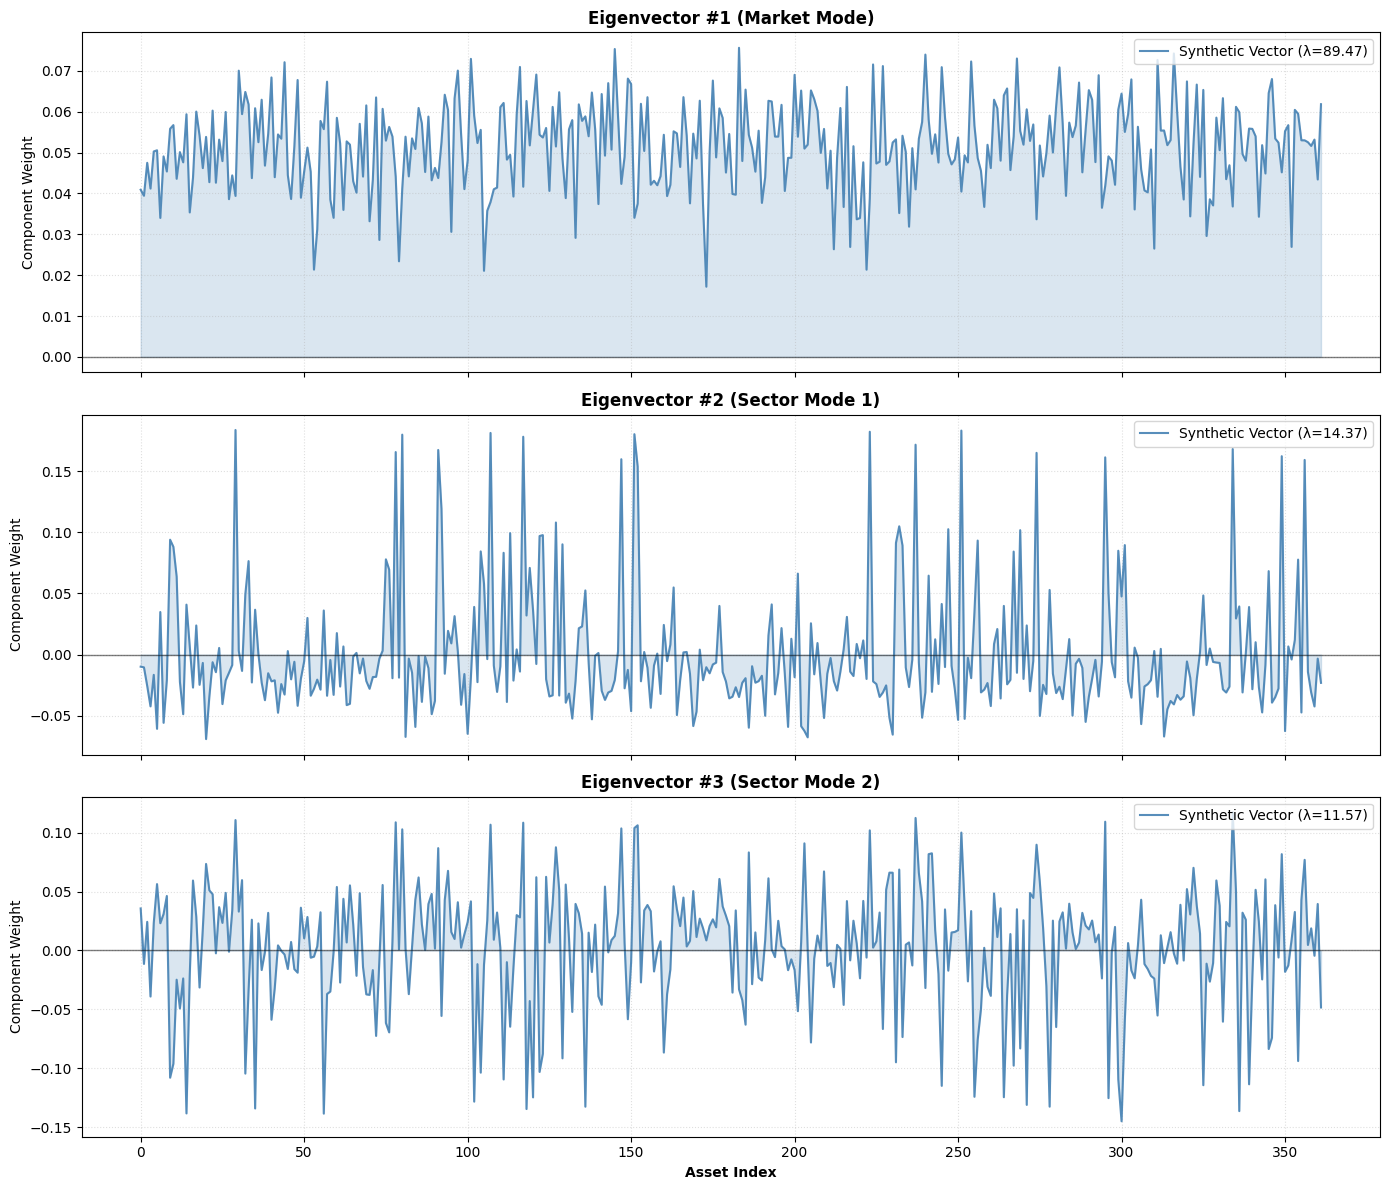

In [62]:
PROPERTY_3_FOLDER = plots_single_dir / 'property3'
PROPERTY_3_FOLDER.mkdir(parents=True, exist_ok=True)

def process_eigenvector(vec):
    """Normalizza il segno dell'autovettore per coerenza (somma positiva)."""
    v = vec.copy()
    if np.sum(v) < 0:
        v = -v
    return v

print(f"\n{'='*65}")
print(f" EIGENVECTOR ANALYSIS (Market & Sector Modes) - Sintetica IDX={IDX}")
print(f"{'='*65}")

# ==========================================
# 2. ESTRAZIONE E ORDINAMENTO
# ==========================================
# Estraiamo gli autovettori dalla matrice rigorosamente PSD
evals_pf, evecs_pf = np.linalg.eigh(synth_mat_psd)

# Ordiniamo in modo decrescente (highest eigenvalues first)
evals_pf = evals_pf[::-1]
evecs_pf = evecs_pf[:, ::-1]

# ==========================================
# 3. PLOT DEI PRIMI 3 AUTOVETTORI
# ==========================================
# Figura con 3 righe, asse X condiviso
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
asset_idx = np.arange(NUM_ASSETS)

for eig_idx in range(3):
    # Estrazione e normalizzazione del segno
    vec_synth = process_eigenvector(evecs_pf[:, eig_idx])
    val_synth = evals_pf[eig_idx]
    
    ax = axes[eig_idx]
    
    # Plot Lineare con Trasparenza e Linee Sottili
    color_map = ['steelblue', 'steelblue', 'steelblue']
    current_color = color_map[eig_idx]
    
    ax.plot(asset_idx, vec_synth, label=f'Synthetic Vector (λ={val_synth:.2f})', 
            color=current_color, lw=1.5, alpha=0.9)
    
    # Riempimento dell'area sotto la curva per migliorare la visibilità dei cluster
    ax.fill_between(asset_idx, 0, vec_synth, color=current_color, alpha=0.2)
    
    # Metriche e Titoli
    mode_name = "Market Mode" if eig_idx == 0 else f"Sector Mode {eig_idx}"
    ax.set_title(f"Eigenvector #{eig_idx+1} ({mode_name})", fontweight='bold', fontsize=12)
    ax.axhline(0, color='black', lw=1, alpha=0.5)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.8)
    ax.set_ylabel('Component Weight')

    # Logica Perron-Frobenius (solo per il primo autovettore, il Market Mode)
    if eig_idx == 0:
        # Usiamo una leggera tolleranza numerica per lo zero assoluto
        pf_synth = np.all(vec_synth >= -1e-4)
        print(f"Eigenvector #1 (Market Mode):")
        print(f"  PF Satisfied : {pf_synth}")
        print(f"  Min Weight   : {np.min(vec_synth):.6f}")
        print(f"  Max Weight   : {np.max(vec_synth):.6f}")
        print("-" * 40)
        if pf_synth:
            print("  ✓ Il Teorema di Perron-Frobenius è Rispettato!")
        else:
            print("  ⚠ Il Teorema non è rigorosamente rispettato (pesi negativi presenti).")

axes[-1].set_xlabel('Asset Index', fontweight='bold')

plt.tight_layout()

# Salvataggio
plot_path = PROPERTY_3_FOLDER / 'synthetic_perron_frobenius.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Eigenvector plot saved to: {plot_path}")

plt.show()

# Property 4: Correlations have a hierarchical structure


Generazione del Dendrogramma (IDX=1)...
✓ Dendrogramma salvato in: ..\generated_matrices\data_00_20_w724_s10\VAE_3dim_0002\idx_1\property4\synthetic_dendrogram.png


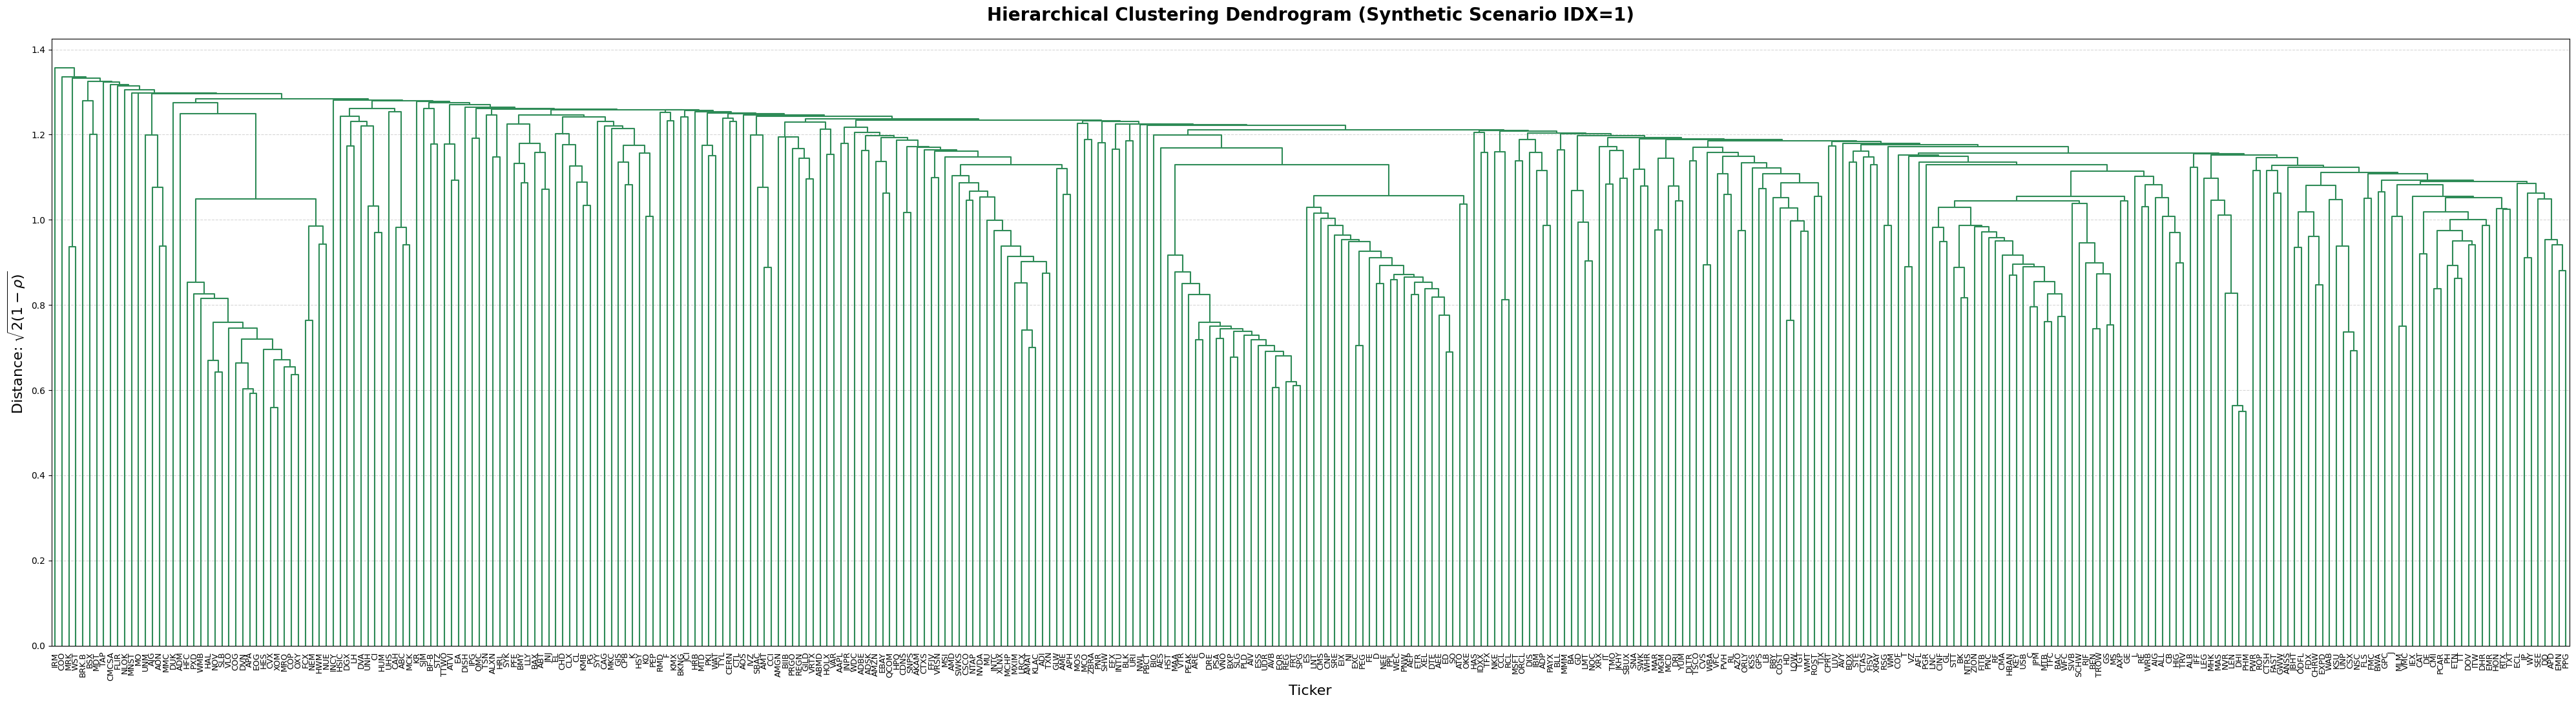

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# ==========================================
# 1. SETUP CARTELLE E FUNZIONI MATEMATICHE
# ==========================================
PROPERTY_4_FOLDER = plots_single_dir / 'property4'
PROPERTY_4_FOLDER.mkdir(parents=True, exist_ok=True)

def sanitize_correlation_matrix(corr_matrix):
    """Garantisce i limiti [-1, 1] e la simmetria perfetta per le distanze."""
    corr_matrix = np.clip(corr_matrix, -1.0, 1.0)
    corr_matrix = (corr_matrix + corr_matrix.T) / 2.0
    np.fill_diagonal(corr_matrix, 1.0)
    return corr_matrix

def build_distance_matrix(corr_matrix):
    """Trasforma la correlazione in distanza metrica: d = sqrt(2*(1-rho))"""
    dist_matrix = np.sqrt(np.maximum(0.0, 2.0 * (1.0 - corr_matrix)))
    dist_matrix = (dist_matrix + dist_matrix.T) / 2.0
    np.fill_diagonal(dist_matrix, 0.0)
    return dist_matrix

print(f"\nGenerazione del Dendrogramma (IDX={IDX})...")

# ==========================================
# 2. PREPARAZIONE DATI E LINKAGE
# ==========================================
sanitized_synth_mat = sanitize_correlation_matrix(synth_mat_psd)
dist_matrix_synth = build_distance_matrix(sanitized_synth_mat)

condensed_dist_synth = squareform(dist_matrix_synth, checks=False)
Z_synth = linkage(condensed_dist_synth, method='average')

# ==========================================
# 3. GENERAZIONE DENDROGRAMMA
# ==========================================
# Impostiamo il rapporto esatto di un tuo singolo subplot precedente (40, 11)
fig, ax = plt.subplots(figsize=(40, 11))

# Definiamo il colore unico per l'intero albero
color_synth = 'seagreen'

dendrogram(
    Z_synth,
    labels=tickers,
    leaf_rotation=90,
    leaf_font_size=9,                             # Riportato a 9 come nel tuo codice originale
    ax=ax,
    color_threshold=0,                            # Disabilita i colori automatici
    above_threshold_color=color_synth,            # Colore per i rami sopra la soglia
    link_color_func=lambda _: color_synth         # Forza lo stesso colore per ogni singolo link
)

ax.set_title(f'Hierarchical Clustering Dendrogram (Synthetic Scenario IDX={IDX})', 
             fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Ticker', fontsize=16)
ax.set_ylabel(r'Distance: $\sqrt{2(1-\rho)}$', fontsize=16)

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# Salvataggio
dendrogram_path = PROPERTY_4_FOLDER / 'synthetic_dendrogram.png'
plt.savefig(dendrogram_path, dpi=300, bbox_inches='tight')

print(f"✓ Dendrogramma salvato in: {dendrogram_path}")
plt.show()

# Property 5: The Minimum Spanning Tree (MST) obtained from a correlation matrix satisfies the scale-free property

Calcolo della topologia MST per lo scenario sintetico (IDX=1)...
✓ Plot MST salvato: ..\generated_matrices\data_00_20_w724_s10\VAE_3dim_0002\idx_1\property5\synthetic_mst_degree_distribution.png


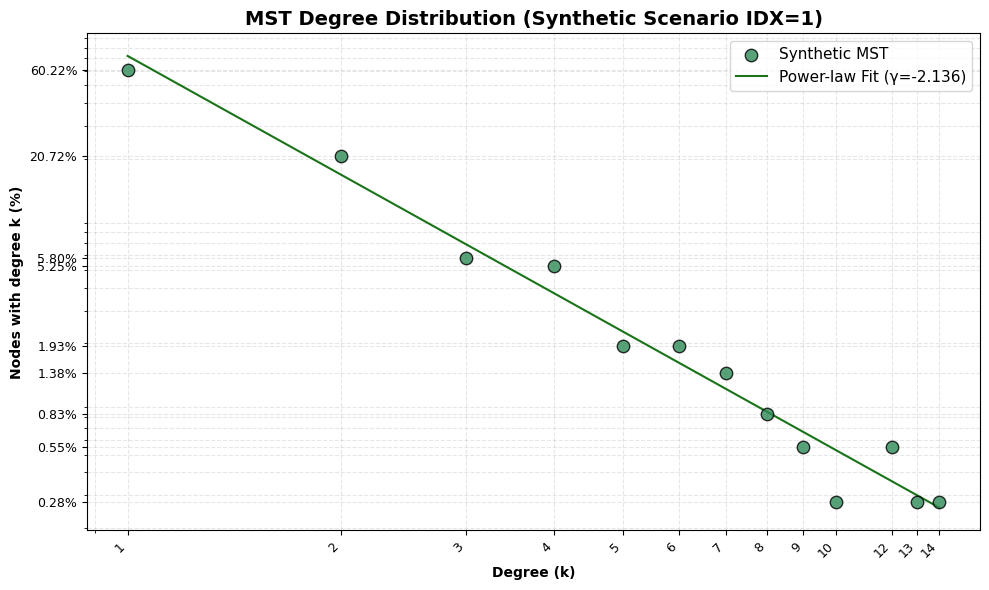


--- Network Topology Stats ---
Max Degree (Market Hub) : 14 connessioni
Leaf Nodes (Degree 1)   : 218 asset (60.2%)
Power-Law Exponent (γ)  : -2.136


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import minimum_spanning_tree

# ==========================================
# 1. SETUP CARTELLE E FUNZIONI
# ==========================================
PROPERTY_5_FOLDER = plots_single_dir / 'property5'
PROPERTY_5_FOLDER.mkdir(parents=True, exist_ok=True)
out_png = PROPERTY_5_FOLDER / 'synthetic_mst_degree_distribution.png'

def compute_degrees_from_mst(adj_matrix):
    """Calcola il grado di ogni nodo da una matrice di adiacenza."""
    adj = np.array(adj_matrix)
    # Il grado è semplicemente la somma delle connessioni per riga
    degrees = np.sum(adj, axis=1).astype(int)
    return degrees

def get_mst_adjacency(matrix):
    """Calcola l'MST da una matrice delle distanze e restituisce l'adiacenza binaria simmetrica."""
    mst_sparse = minimum_spanning_tree(matrix)
    mst_binary = (mst_sparse.toarray() > 0).astype(int)
    mst_full = mst_binary + mst_binary.T
    return mst_full

# ==========================================
# 2. CALCOLO MST E GRADI
# ==========================================
print(f"Calcolo della topologia MST per lo scenario sintetico (IDX={IDX})...")

# Usiamo la matrice delle distanze calcolata nella Property 4
# (Se hai riavviato il kernel, assicurati che 'dist_matrix_synth' sia in memoria)
adj_synth = get_mst_adjacency(dist_matrix_synth)
deg_synth = compute_degrees_from_mst(adj_synth)

# ==========================================
# 3. FUNZIONE DI PLOT E FIT (Legge di Potenza)
# ==========================================
def plot_single_degree_distribution(deg_data, out_path):
    max_degree = int(deg_data.max())
    counts = np.bincount(deg_data, minlength=max_degree + 1)
    freq = counts / counts.sum()

    degrees_arr = np.arange(max_degree + 1)
    mask = freq > 0
    
    x_val = degrees_arr[mask & (degrees_arr > 0)]
    y_val = freq[mask & (degrees_arr > 0)] * 100.0

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Scatter plot dei gradi
    ax.scatter(x_val, y_val, s=80, alpha=0.8, color='seagreen', marker='o', 
               edgecolor='black', label='Synthetic MST', zorder=3)

    # Gestione Assi Log-Log con tick esatti
    all_x = np.unique(x_val)
    if len(all_x) > 0:
        ax.set_xscale('log')
        ax.set_xticks(all_x)
        ax.set_xticklabels([f'{int(k)}' for k in all_x], rotation=45, ha='right', fontsize=9)

    all_y = np.unique(y_val)
    if len(all_y) > 0:
        ax.set_yscale('log')
        ax.set_yticks(all_y)
        ax.set_yticklabels([f'{val:.2f}%' for val in all_y], fontsize=9)

    # Fit della Legge di Potenza (Power-Law)
    if len(x_val) >= 2:
        slope, intercept = np.polyfit(np.log10(x_val), np.log10(y_val), 1)
        y_fit = 10 ** (intercept + slope * np.log10(x_val))
        
        ax.plot(x_val, y_fit, color='darkgreen', lw=1.5, ls='-', alpha=0.9, 
                label=f'Power-law Fit (γ={slope:.3f})')

    # Estetica
    ax.set_xlabel('Degree (k)', fontweight='bold')
    ax.set_ylabel('Nodes with degree k (%)', fontweight='bold')
    ax.set_title(f'MST Degree Distribution (Synthetic Scenario IDX={IDX})', fontweight='bold', fontsize=14)
    ax.grid(True, which="both", ls="--", alpha=0.3)
    ax.legend(frameon=True, loc='best', fontsize=11)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'✓ Plot MST salvato: {out_path}')
    plt.show()

    # Statistiche di Rete
    print(f"\n--- Network Topology Stats ---")
    print(f"Max Degree (Market Hub) : {max_degree} connessioni")
    print(f"Leaf Nodes (Degree 1)   : {counts[1]} asset ({freq[1]*100:.1f}%)")
    if len(x_val) >= 2:
        print(f"Power-Law Exponent (γ)  : {slope:.3f}")

# Esecuzione
plot_single_degree_distribution(deg_synth, out_png)

--- Generazione grafici di Rete per: SYNTHETIC_IDX_1 ---
✓ PNG salvato in: ..\generated_matrices\data_00_20_w724_s10\VAE_3dim_0002\idx_1\property5\synthetic_idx_1_mst_graph.png


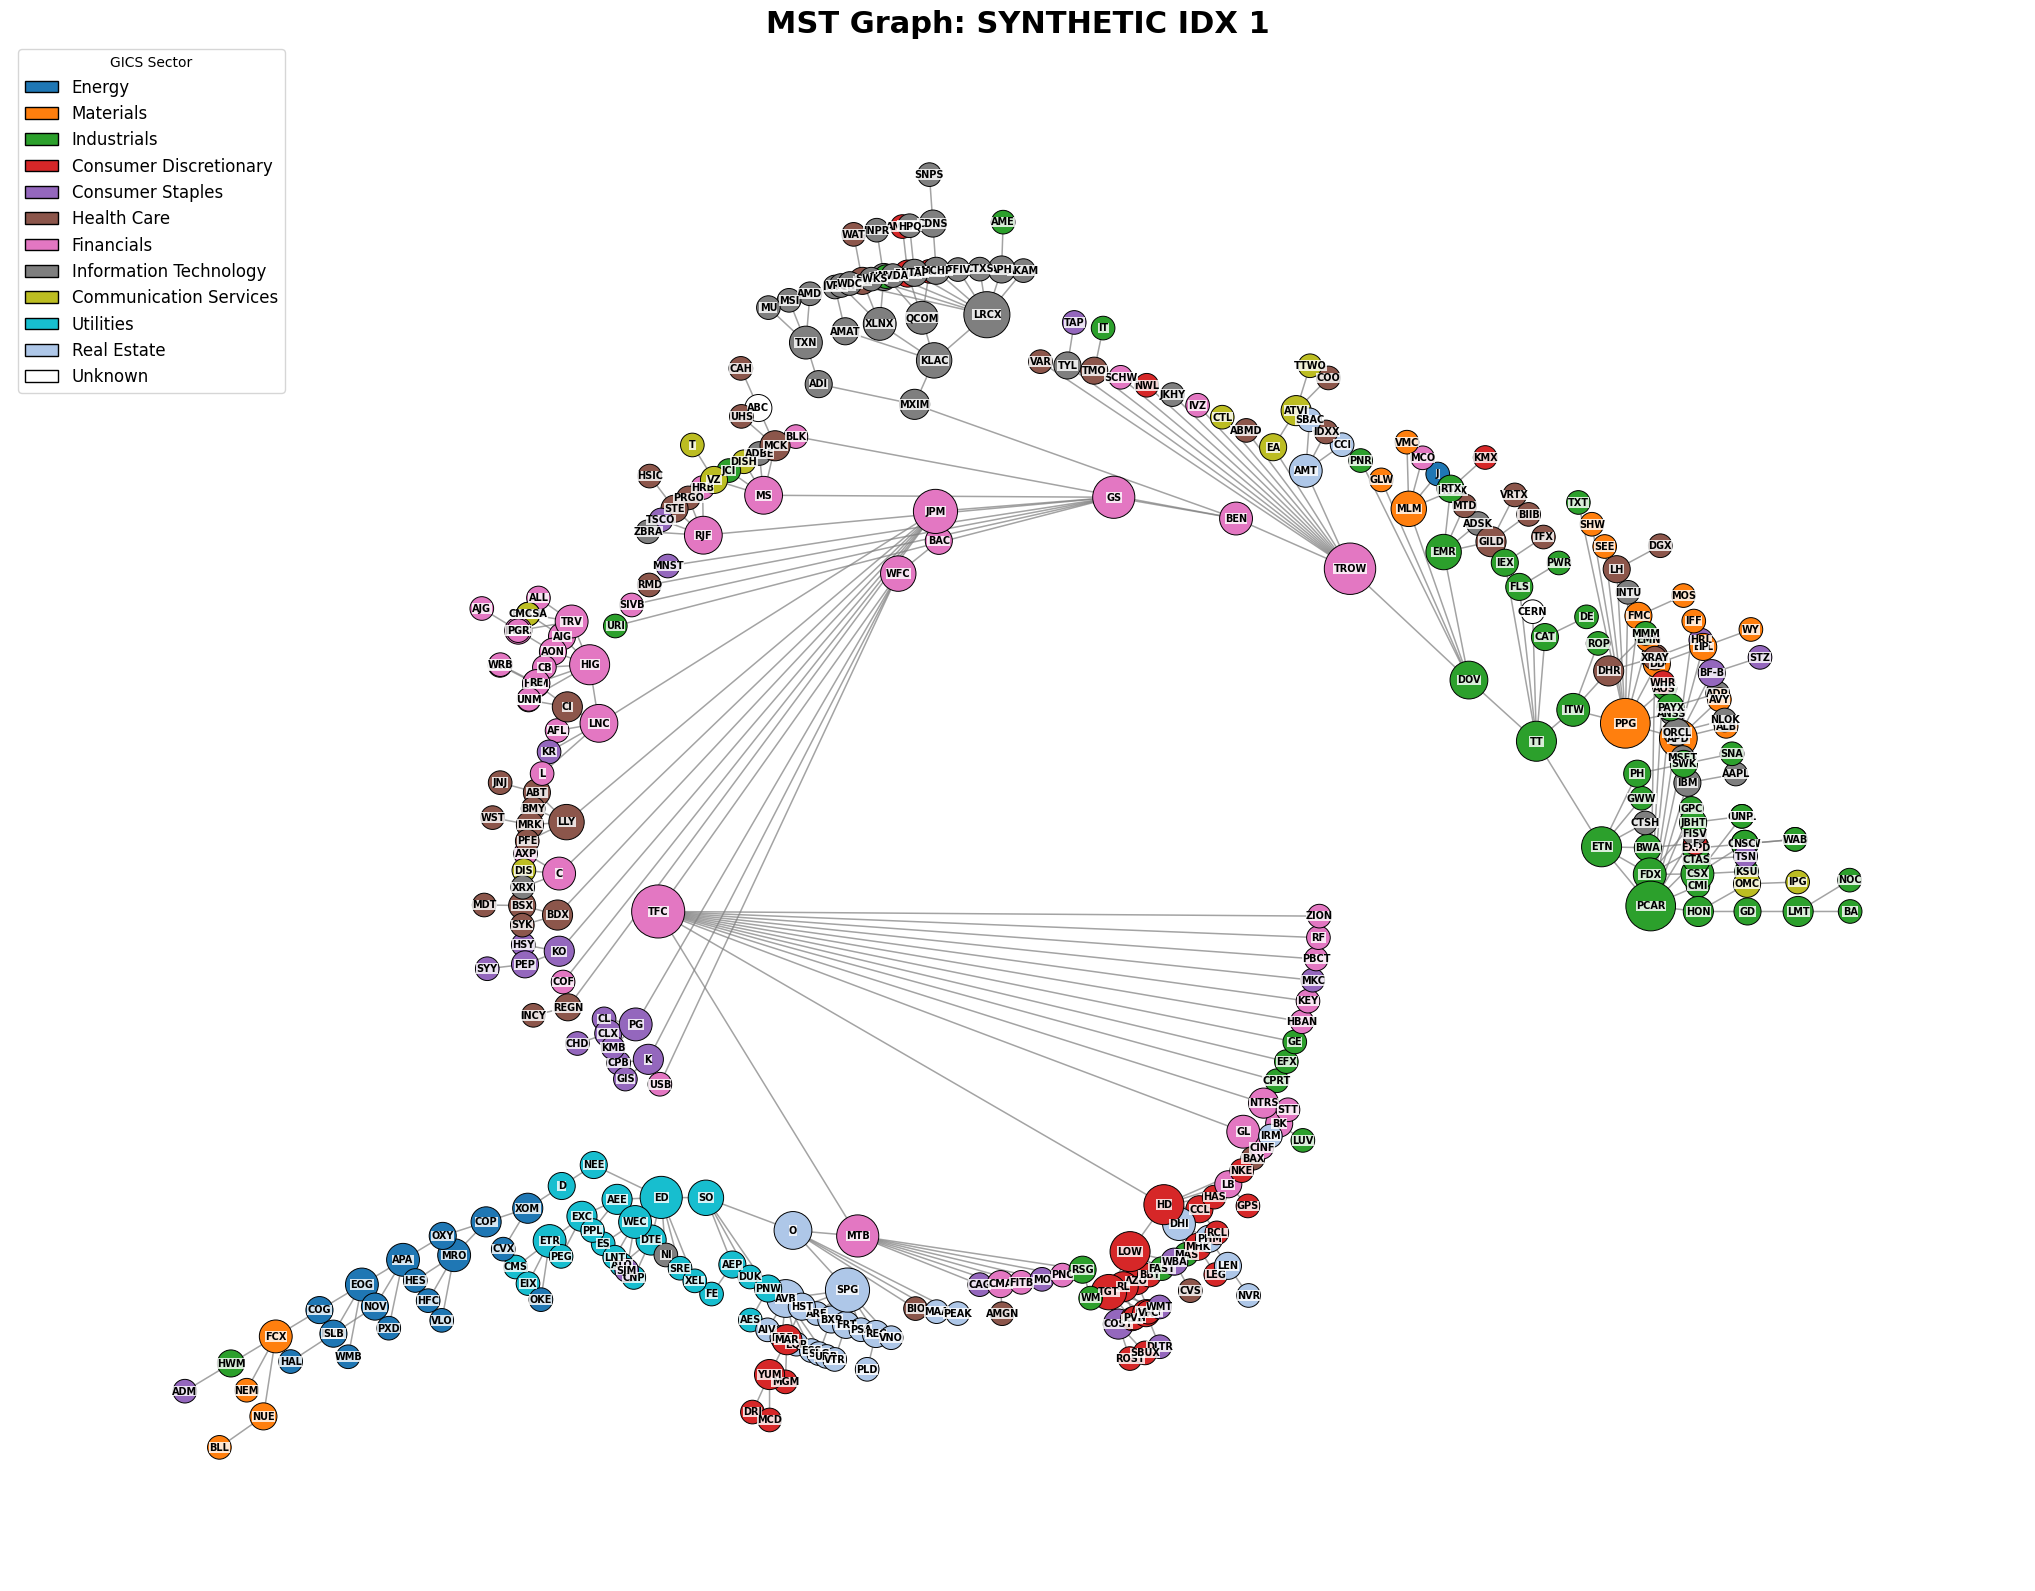

✓ Mappa Interattiva PyVis (HTML) salvata in: ..\generated_matrices\data_00_20_w724_s10\VAE_3dim_0002\idx_1\property5\synthetic_idx_1_mst_graph_pyvis.html


In [65]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ==========================================
# 1. FUNZIONI DI LAYOUT E SUPPORTO
# ==========================================
def radial_tree_layout(tree, root=None, min_radius=0.35, max_radius=1.0, radial_power=1.35, angle_gap=0.035):
    if len(tree) == 0:
        return {}, None
    if root is None:
        root = max(tree.degree, key=lambda x: x[1])[0]

    bfs_tree = nx.bfs_tree(tree, root)
    children = {n: list(bfs_tree.successors(n)) for n in bfs_tree.nodes()}
    leaf_counts = {}

    def compute_leaf_counts(node):
        kids = children.get(node, [])
        if not kids:
            leaf_counts[node] = 1
            return 1
        total = sum(compute_leaf_counts(child) for child in kids)
        leaf_counts[node] = total
        return total

    compute_leaf_counts(root)
    depths = nx.single_source_shortest_path_length(bfs_tree, root)
    max_depth = max(depths.values()) if depths else 0
    pos = {}

    def assign_angles(node, angle_start, angle_end):
        angle = 0.5 * (angle_start + angle_end)
        depth = depths.get(node, 0)
        radius = min_radius + (max_radius - min_radius) * ((depth / max_depth) ** radial_power) if max_depth > 0 else 0.0
        pos[node] = np.array([radius * np.cos(angle), radius * np.sin(angle)])

        kids = children.get(node, [])
        if not kids: return
        kids = sorted(kids, key=lambda n: (-leaf_counts.get(n, 1), str(n)))
        span = angle_end - angle_start
        gap = max(0.0, angle_gap)
        total_gap = gap * max(0, len(kids) - 1)
        available_span = max(1e-6, span - total_gap)
        total = sum(leaf_counts.get(k, 1) for k in kids)
        current = angle_start
        for child in kids:
            frac = leaf_counts.get(child, 1) / total
            child_span = available_span * frac
            assign_angles(child, current, current + child_span)
            current += child_span + gap

    assign_angles(root, 0.0, 2.0 * np.pi)
    return pos, root

def generate_mst_visuals(matrix, tickers_list, gics_map, color_map, sector_order, output_prefix, folder):
    """
    Crea MST, grafico statico PNG (salvato e mostrato) e interattivo HTML.
    """
    print(f"--- Generazione grafici di Rete per: {output_prefix.upper()} ---")
    
    # Costruzione distanze usando le funzioni già definite
    corr_matrix = sanitize_correlation_matrix(matrix)
    dist_matrix = build_distance_matrix(corr_matrix)

    # Build MST
    G = nx.from_numpy_array(dist_matrix)
    mst = nx.minimum_spanning_tree(G, weight='weight')
    node_labels = {i: str(tickers_list[i]) for i in range(len(tickers_list))}
    mst_labeled = nx.relabel_nodes(mst, node_labels)

    # Gradi e Settori
    degree_dict = dict(mst_labeled.degree())
    node_names = list(mst_labeled.nodes())
    node_degrees = np.array([degree_dict[n] for n in node_names], dtype=float)
    node_sectors = [gics_map.get(str(n).upper(), "Unknown") for n in node_names]
    node_colors = [color_map.get(sector, "#9e9e9e") for sector in node_sectors]
    
    unique_sectors = [s for s in sector_order if s in set(node_sectors)]
    if "Unknown" not in unique_sectors: unique_sectors.append("Unknown")

    # Layout
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        root_node = max(mst_labeled.degree, key=lambda x: x[1])[0]
        pos = graphviz_layout(mst_labeled, prog="twopi", root=root_node,
                              args="-Goverlap=false -Gsep=+0.8 -Granksep=1.1 -Gnodesep=0.4")
    except Exception:
        pos, root_node = radial_tree_layout(mst_labeled)

    # Normalize pos
    pos_keys = list(pos.keys())
    pos_arr = np.array([pos[k] for k in pos_keys], dtype=float)
    mins, maxs = pos_arr.min(axis=0), pos_arr.max(axis=0)
    pos_arr = (pos_arr - mins) / np.maximum(maxs - mins, 1e-12)
    pos_arr = pos_arr * 1.9 - 0.95
    pos = {k: pos_arr[idx] for idx, k in enumerate(pos_keys)}

    # ==========================================
    # PLOT MATPLOTLIB (PNG)
    # ==========================================
    fig = plt.figure(figsize=(26, 20))
    ax = fig.add_subplot(111)
    
    nx.draw_networkx_edges(mst_labeled, pos, width=1.1, alpha=0.72, edge_color='gray', ax=ax)
    nx.draw_networkx_nodes(mst_labeled, pos, nodelist=node_names, 
                           node_size=200 + 90 * node_degrees, node_color=node_colors, 
                           edgecolors='black', linewidths=0.7, ax=ax)
    nx.draw_networkx_labels(mst_labeled, pos, font_size=7, font_weight='bold', 
                            bbox=dict(facecolor='white', edgecolor='none', alpha=0.82, pad=0.2), ax=ax)
    
    legend_handles = [Patch(facecolor=color_map[s], edgecolor='black', label=s) for s in unique_sectors]
    ax.legend(handles=legend_handles, title="GICS Sector", loc="upper left", fontsize=12)
    ax.set_title(f'MST Graph: {output_prefix.replace("_", " ").upper()}', fontsize=22, fontweight='bold')
    ax.axis('off')
    
    # Salva il file PNG
    plot_path = folder / f'{output_prefix}_mst_graph.png'
    fig.savefig(plot_path, dpi=220, bbox_inches='tight')
    print(f"✓ PNG salvato in: {plot_path}")
    
    plt.show() 
    plt.close(fig)

    # ==========================================
    # PLOT PYVIS (HTML INTERATTIVO)
    # ==========================================
    try:
        from pyvis.network import Network
        pyvis_path = folder / f"{output_prefix}_mst_graph_pyvis.html"
        net = Network(height="900px", width="100%", bgcolor="#ffffff", font_color="black")
        net.barnes_hut(gravity=-20000, central_gravity=0.25, spring_length=220, spring_strength=0.01, damping=0.9)
        
        for name, degree, sector in zip(node_names, node_degrees, node_sectors):
            x, y = pos.get(name, (0.0, 0.0))
            node_title = f"{name} | {sector} | Degree: {int(degree)}"
            net.add_node(name, label=str(name), title=node_title, 
                         color=color_map.get(sector, "#9e9e9e"), size=10 + 6 * degree,
                         x=float(x * 1000), y=float(y * 1000))
        for u, v in mst_labeled.edges():
            net.add_edge(u, v, color="#999999")
        
        net.save_graph(str(pyvis_path))
        print(f"✓ Mappa Interattiva PyVis (HTML) salvata in: {pyvis_path}")
    except Exception as e:
        print(f"⚠ Errore PyVis (assicurati di aver fatto 'pip install pyvis'): {e}")

# ==========================================
# 2. CONFIGURAZIONE DATI E COLORI GICS
# ==========================================
# Assicurati che questo path sia corretto nel tuo file system
gics_path = Path(r"..\data\processed\gics_by_ticker.csv")
if not gics_path.exists():
    print(f"⚠ Attenzione: File GICS non trovato in {gics_path}. I nodi saranno grigi.")
    gics_map = {}
else:
    gics_df = pd.read_csv(gics_path)
    gics_df["ticker"] = gics_df["ticker"].astype(str).str.upper()
    gics_map = dict(zip(gics_df["ticker"], gics_df["gics_category"]))

sector_order = [
    "Energy", "Materials", "Industrials", "Consumer Discretionary", "Consumer Staples",
    "Health Care", "Financials", "Information Technology", "Communication Services",
    "Utilities", "Real Estate", "Unknown",
]

sector_colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", 
    "#aec7e8", "#ffffff",
]
color_map = {sector: sector_colors[i] for i, sector in enumerate(sector_order)}

# ==========================================
# 3. ESECUZIONE 
# ==========================================
# Usiamo la cartella property5 creata in precedenza
generate_mst_visuals(
    matrix=synth_mat_psd, 
    tickers_list=tickers, 
    gics_map=gics_map, 
    color_map=color_map, 
    sector_order=sector_order, 
    output_prefix=f"synthetic_idx_{IDX}", 
    folder=PROPERTY_5_FOLDER
)